In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.environ['KAGGLE_CONFIG_DIR'] = "/content"
os.environ['KAGGLE_USERNAME'] = "habiburrehman07" 
os.environ['KAGGLE_KEY'] = "480a07a03a5ccd045afeeacca1106d04" 

In [ ]:
import os

!pip install kaggle -q

!kaggle datasets download -d xhlulu/140k-real-and-fake-faces

!unzip -q 140k-real-and-fake-faces.zip -d /content/local_dataset

!ls -F /content/local_dataset

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:38<00:00, 105MB/s] 

real_vs_fake/  test.csv  train.csv  valid.csv


In [ ]:
DATASET_PATH = "/content/local_dataset/real_vs_fake/real-vs-fake"

In [ ]:
train_dir = DATASET_PATH + "/train"
val_dir   = DATASET_PATH + "/valid"
test_dir  = DATASET_PATH + "/test"
import os
os.listdir(train_dir)

['real', 'fake']

In [ ]:
!pip install tensorflow pillow matplotlib opencv-python

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:

train_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224 , 224), 
    batch_size=64,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(224 , 224),
    batch_size=64,
    class_mode='binary'
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Fine-tuning: freeze early layers only
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

# Custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)   # reduces overfitting
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,  
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2  
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1575s 985ms/step - accuracy: 0.8720 - loss: 0.2902 - val_accuracy: 0.9469 - val_loss: 0.1382 - learning_rate: 1.0000e-04
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1511s 967ms/step - accuracy: 0.9439 - loss: 0.1440 - val_accuracy: 0.8565 - val_loss: 0.4298 - learning_rate: 1.0000e-04
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1497s 957ms/step - accuracy: 0.9608 - loss: 0.1038 - val_accuracy: 0.9524 - val_loss: 0.1330 - learning_rate: 1.0000e-04
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1489s 953ms/step - accuracy: 0.9688 - loss: 0.0828 - val_accuracy: 0.9301 - val_loss: 0.2489 - learning_rate: 1.0000e-04
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1489s 952ms/step - accuracy: 0.9740 - loss: 0.0697 - val_accuracy: 0.9681 - val_loss: 0.0939 - learning_rate: 1.0000e-04
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1482s 948ms/step - accuracy: 0.9778 - loss: 0.0592 - val_accuracy: 0.9496 - val_loss: 0.1686 - learning_rate: 1.0000e-04
Epoch 7/15
1563/1563 ━

In [ ]:
model.save("/content/drive/MyDrive/Trace_fake_Project/tracefake_model22.keras")
print("✅ Model saved!")

✅ Model saved!


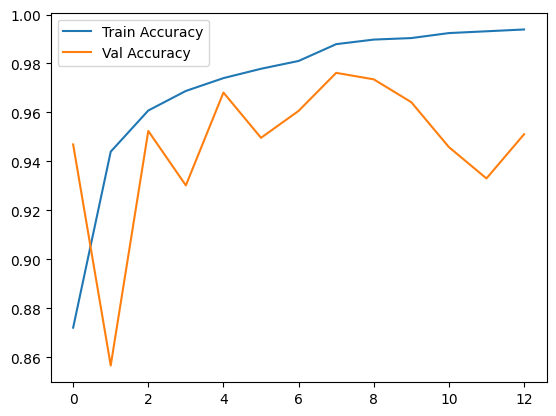

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

In [14]:
import tensorflow as tf
model = tf.keras.models.load_model('models/tracefake_modelii.keras')

In [28]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 6,473,157 (24.69 MB)

 Trainable params: 2,025,537 (7.73 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 4,051,076 (15.45 MB)

In [16]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_image(img_path):
    img = load_img(img_path, target_size=(224,224))
    img = img_to_array(img)/255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    if pred > 0.5:
        return "Fake", pred
    else:
        return "Real", 1 - pred

In [17]:
test_image = "/Users/mhabi/Desktop/HAB/Trace_Fake/test.jpg"  

label, confidence = predict_image(test_image)

print("Prediction:", label)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Prediction: Real
Confidence: 0.9999953


In [34]:
from PIL import Image, ImageChops, ImageEnhance

def perform_ela(img_path):
    original = Image.open(img_path).convert('RGB')
    temp_path = "temp_ela.jpg"
    original.save(temp_path, 'JPEG', quality=90)
    resaved = Image.open(temp_path)
    ela_img = ImageChops.difference(original, resaved)
    extrema = ela_img.getextrema()
    max_diff = max([ex[1] for ex in extrema]) or 1
    ela_img = ImageEnhance.Brightness(ela_img).enhance(255.0 / max_diff)
    os.remove(temp_path)
    return ela_img

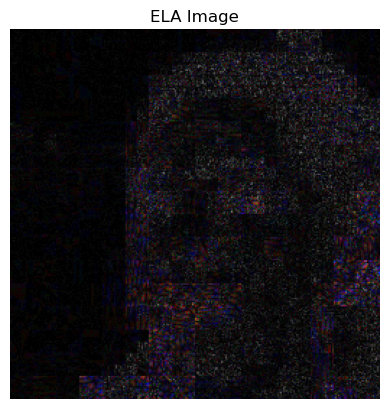

In [35]:
import matplotlib.pyplot as plt
ela_img = perform_ela(test_image)

plt.imshow(ela_img)
plt.title("ELA Image")
plt.axis("off")
plt.show()

In [ ]:
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

loss, acc = model.evaluate(test_data)

print("Test Accuracy:", acc)

Found 20000 images belonging to 2 classes.
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.9770 - loss: 0.0692
Test Accuracy: 0.9769999980926514


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

true_labels = test_data.classes

predictions_proba = model.predict(test_data)

predicted_labels = (predictions_proba > 0.5).astype(int)

625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step


### Confusion Matrix

In [ ]:
conf_matrix = confusion_matrix(true_labels, predicted_labels)
print('Confusion Matrix:')
print(conf_matrix)

Confusion Matrix:
[[9577  423]
 [  37 9963]]


### Classification Report

In [ ]:
target_names = list(test_data.class_indices.keys())
print('Classification Report:')
print(classification_report(true_labels, predicted_labels, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

        fake       1.00      0.96      0.98     10000
        real       0.96      1.00      0.98     10000

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000



<h3> EXIF Read 

In [ ]:
pip install exifread

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/59.7 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
import exifread

def get_exif(img_path):
    with open(img_path, 'rb') as f:
        tags = exifread.process_file(f)

    data = {
        "Camera Model": tags.get('Image Model', 'Unknown'),
        "Software": tags.get('Image Software', 'None Detected'),
        "Date Taken": tags.get('EXIF DateTimeOriginal', 'Not Available'),
        "GPS Info": "None" if not tags.get('GPS GPSLatitude') else "Available"
    }
    return data

In [ ]:
get_exif(test_image)

{'Camera Model': 'Unknown',
 'Software': 'None Detected',
 'Date Taken': 'Not Available',
 'GPS Info': 'None'}

<h3> ELA Part


In [ ]:
import os
import numpy as np
from PIL import Image, ImageChops, ImageEnhance

_ELA_QUALITY = 90    
_REAL_MEAN   = 5.0   
_FAKE_MEAN   = 20.0  


def perform_ela(img_path: str, quality: int = _ELA_QUALITY) -> Image.Image:
    
    original = Image.open(test.jpg).convert("RGB")
    temp_path = "_ela_tmp.jpg"
    original.save(temp_path, "JPEG", quality=quality)
    resaved  = Image.open(temp_path)
    ela_img  = ImageChops.difference(original, resaved)
    extrema  = ela_img.getextrema()
    max_diff = max([ex[1] for ex in extrema]) or 1
    ela_img  = ImageEnhance.Brightness(ela_img).enhance(255.0 / max_diff)
    os.remove(temp_path)
    return ela_img


def ela_tamper_score(img_path: str) -> dict:

    ela_img  = perform_ela(img_path)
    arr      = np.array(ela_img, dtype=np.float32)
    mean_diff = float(np.mean(arr))

    # Linear interpolation, clamped to [0, 1]
    fake_prob = (mean_diff - _REAL_MEAN) / (_FAKE_MEAN - _REAL_MEAN)
    fake_prob = float(np.clip(fake_prob, 0.0, 1.0))

    return {
        "ela_image": ela_img,
        "mean_diff": round(mean_diff, 2),
        "fake_prob": round(fake_prob, 3),
    }


<h3>GAN

In [ ]:

import numpy as np
import cv2
from scipy.fftpack import fft2, fftshift
from PIL import Image

_REAL_RATIO = 0.60  
_FAKE_RATIO = 0.85   


def _compute_spectrum(image_path: str) -> tuple:
 
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    f_shift   = fftshift(fft2(gray))
    spectrum  = np.log(np.abs(f_shift) + 1)
    return spectrum, gray


def detect_gan_fingerprint(image_path: str) -> dict:

    spectrum, _ = _compute_spectrum(image_path)

    h, w = spectrum.shape
    ch, cw = h // 2, w // 2

   
    high_freq = spectrum.copy()
    high_freq[ch - 30: ch + 30, cw - 30: cw + 30] = 0

    freq_ratio = float(np.mean(high_freq) / (np.mean(spectrum) + 1e-6))

    fake_prob = (freq_ratio - _REAL_RATIO) / (_FAKE_RATIO - _REAL_RATIO)
    fake_prob = float(np.clip(fake_prob, 0.0, 1.0))

    return {
        "fake_prob":  round(fake_prob, 3),
        "freq_ratio": round(freq_ratio, 4),
        "spectrum":   spectrum,
    }


def spectrum_to_pil(spectrum: np.ndarray) -> Image.Image:

    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import io

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(spectrum, cmap="hot")
    ax.set_title("GAN Fingerprint\n(Freq. Spectrum)", fontsize=9)
    ax.axis("off")
    plt.tight_layout(pad=0.5)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).copy()
